In [4]:
import importlib
import libpysal
import geopandas as gpd
import tools
importlib.reload(tools)
from spopt.region import Skater, WardSpatial
from sklearn.preprocessing import StandardScaler
import itertools

In [5]:
shapes = ['square', 'pent', 'hex']
sizes = [100, 400]
z_runs = range(10) # Zonations 0-9
n_variables = 5 
scaler = StandardScaler()

In [6]:
for shape, size in itertools.product(shapes, sizes):
    print(f"{shape} - Size: {size}...")

    gdf = gpd.read_parquet(f"data/regionalization/gdf_{shape}_{size}.parquet")
    w = libpysal.graph.read_parquet(f"graphs/{shape}/size_{size}/g_true.parquet").to_W()

    for z_run in z_runs:
        cluster_variables = [f"zone_run{z_run}_run{v}" for v in range(n_variables)]
        var_scaled = StandardScaler().fit_transform(gdf[cluster_variables].values)

        local_gdf = gpd.GeoDataFrame(geometry=gdf.geometry)
        temp_cols = [f"v_{i}" for i in range(n_variables)]
        local_gdf[temp_cols] = var_scaled

        # SCHC
        try:
            model_ward = WardSpatial(
                gdf=local_gdf,
                w=w,
                attrs_name=temp_cols,
                n_clusters=5
            )
            model_ward.solve()
            gdf[f"true_ward_zone{z_run}"] = model_ward.labels_
        except Exception as e:
            print(f"  WardSpatial failed for z_run {z_run}: {e}")
            gdf[f"true_ward_zone{z_run}"] = -1

        # SKATER
        try:
            model_skater = Skater(
                gdf=local_gdf,
                w=w,
                attrs_name=temp_cols,
                n_clusters=5,
                floor=1,
                islands="error"
            )
            model_skater.solve()
            gdf[f"true_skater_zone{z_run}"] = model_skater.labels_
        except Exception as e:
            print(f"  Skater failed for z_run {z_run}: {e}")
            gdf[f"true_skater_zone{z_run}"] = -1

    gdf.to_parquet(f"data/regionalization/gdf_{shape}_{size}.parquet")
    print(f"  Saved gdf_{shape}_{size}.parquet\n")

square - Size: 100...
  Saved gdf_square_100.parquet

square - Size: 400...
  Saved gdf_square_400.parquet

pent - Size: 100...
  Saved gdf_pent_100.parquet

pent - Size: 400...
  Saved gdf_pent_400.parquet

hex - Size: 100...
  Saved gdf_hex_100.parquet

hex - Size: 400...
  Saved gdf_hex_400.parquet



<Axes: >

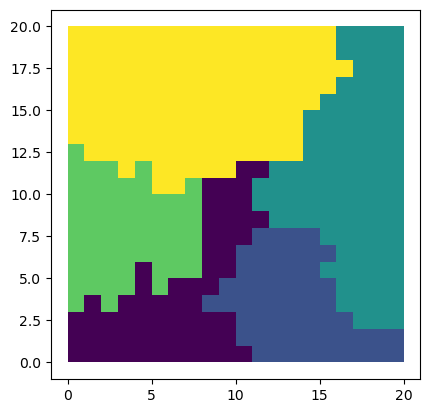

In [70]:
gdf.plot(column = "true_predicted_zone9_skater")

<Axes: >

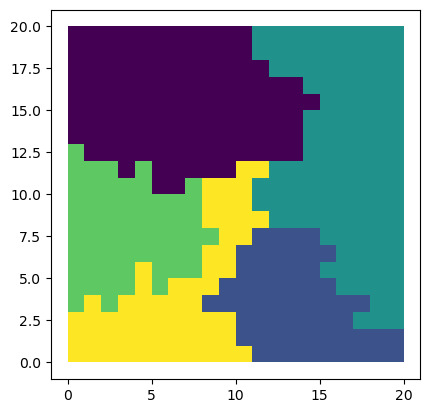

In [71]:
gdf.plot(column = "true_predicted_zone9_agg")

<Axes: >

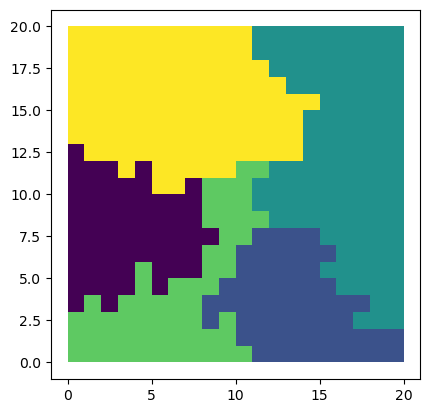

In [72]:
gdf.plot(column = "zone_id_9")